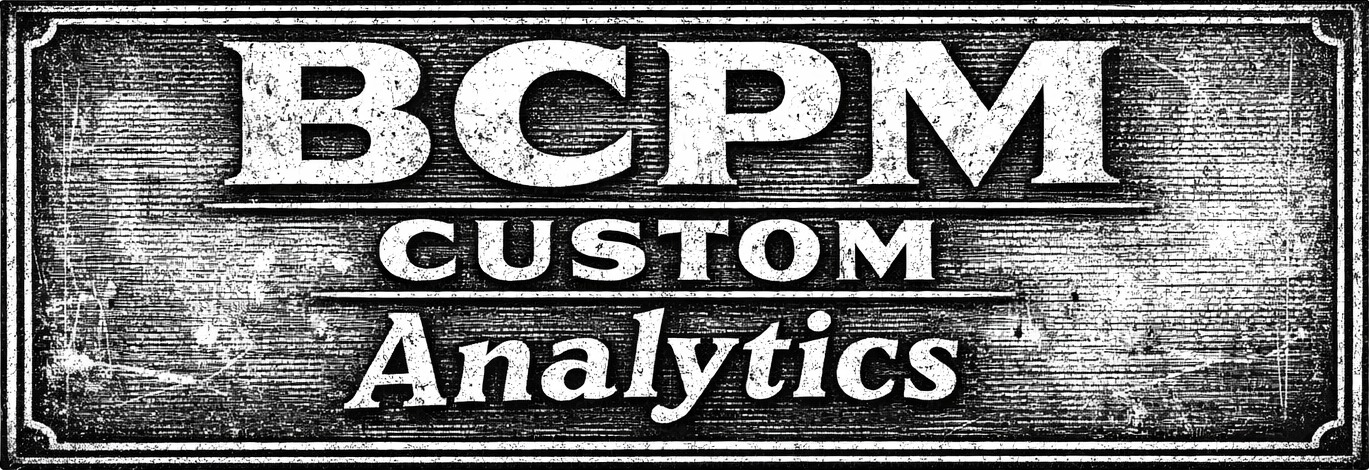

# MintClassics Warehouse Elimination Study

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

In [2]:
data_file = 'CSV_Files/productLinesInfo.csv'

In [3]:
df = pd.read_csv(data_file)
df.head()

,warehouseCode,productCode,productLine,productVendor,buyPrice,quantityInStock,investmentValue,priceEach,quantitySold,lineRevenue,grossRevenue
0,a,S10_1678,Motorcycles,Min Lin Diecast,48.81,7933,387209.73,81.35,124,244.05,30262.20
1,a,S10_1678,Motorcycles,Min Lin Diecast,48.81,7933,387209.73,86.13,34,86.13,2928.42
2,a,S10_1678,Motorcycles,Min Lin Diecast,48.81,7933,387209.73,90.92,82,181.84,14910.88
3,a,S10_1678,Motorcycles,Min Lin Diecast,48.81,7933,387209.73,76.56,118,306.24,36136.32
4,a,S10_1678,Motorcycles,Min Lin Diecast,48.81,7933,387209.73,94.74,77,189.48,14589.96


## Initial inspection of stock on hand by warehouse location

- The first thing to check is the distribution of product stock according to which warehouse location the stock is being stored.

In [4]:
warehouse_data = df.groupby('warehouseCode')[['quantityInStock', 'investmentValue']].sum().reset_index()
warehouse_data

,warehouseCode,quantityInStock,investmentValue
0,a,2035676,1.033236e+08
1,b,3265557,2.125878e+08
2,c,1941757,8.882738e+07
3,d,1264110,6.573173e+07


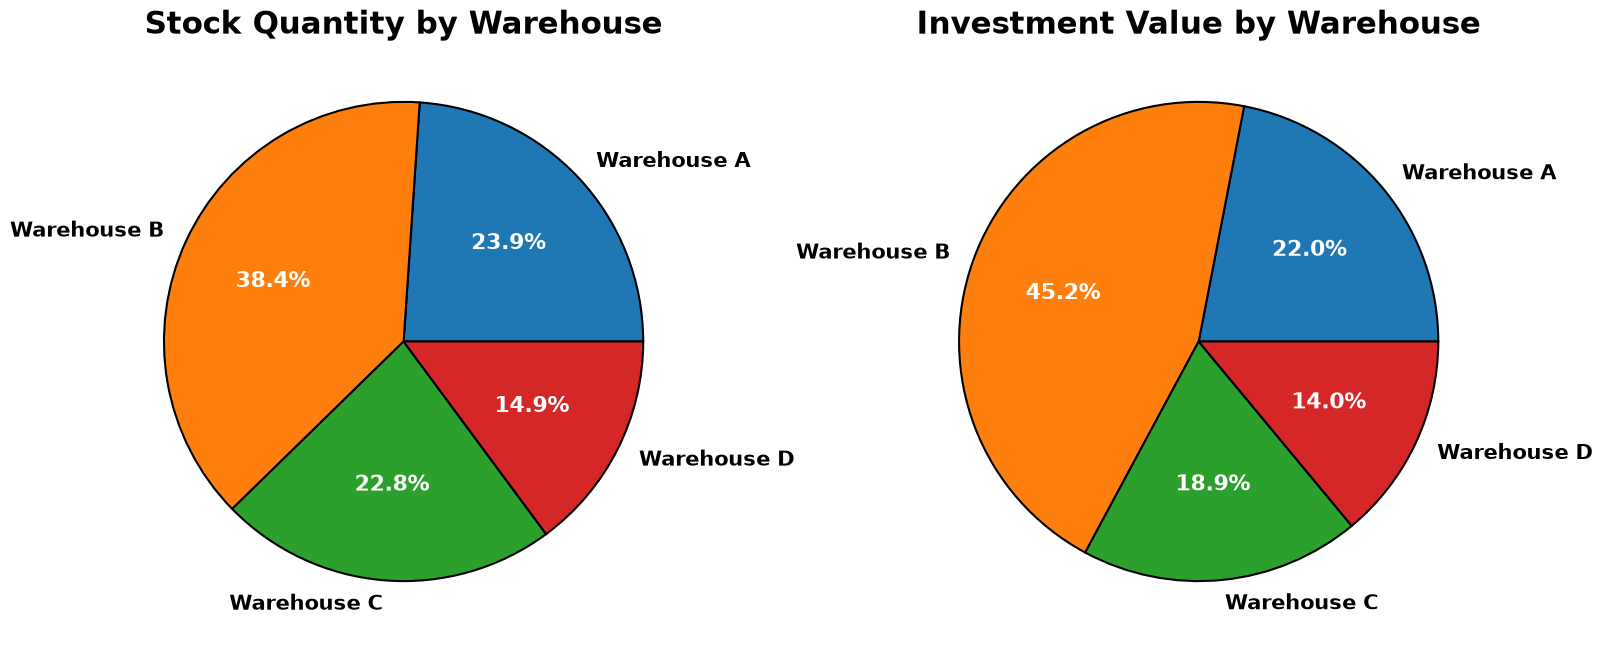

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

labels = ['Warehouse A', 'Warehouse B', 'Warehouse C', 'Warehouse D']

wedges0, texts0, autotexts0 = ax[0].pie(
    warehouse_data.quantityInStock, 
    labels=labels, 
    autopct='%1.1f%%', 
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5}
)
ax[0].set_title('Stock Quantity by Warehouse', fontsize=22, weight='bold')
plt.setp(autotexts0, size=16, weight="bold", color="white")
plt.setp(texts0, size=15, weight="bold")

wedges1, texts1, autotexts1 = ax[1].pie(
        warehouse_data.investmentValue,
        labels=labels,
        autopct='%1.1f%%',
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.5}
         )
ax[1].set_title('Investment Value by Warehouse', fontsize=22, weight='bold')
plt.setp(autotexts1, size=16, weight="bold", color="white")
plt.setp(texts1, size=15, weight="bold")

plt.tight_layout()
plt.show()
plt.close('all')



- The majority of product stock is stored in Warehouse A.
- The cost of the stock in Warehouse A is comparatively higher than the cost of the stock stored in any of the other warehouses as demonstrated by the 'Investment Value' being 6% higher than the 'Stock Quantity'

## Check Customer Locations

- Where does each warehouse ship it's products?
- Does each warehouse service it's own geographic location?

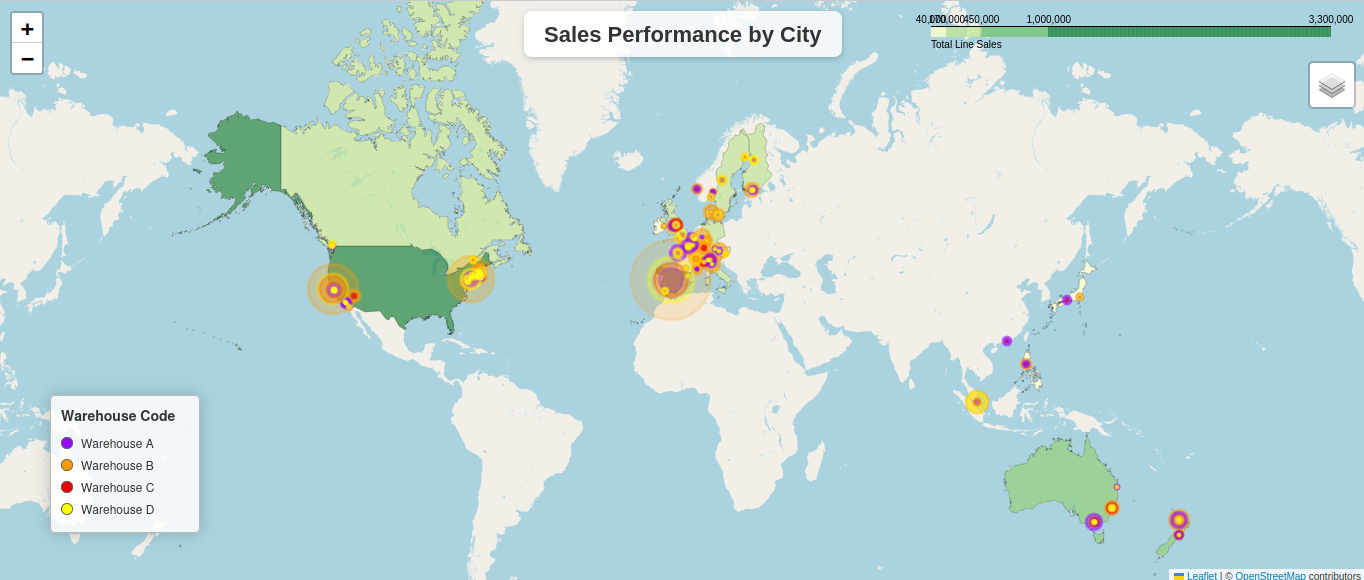

- The map shows that each of the four warehouses ship to all customer regions.

## Check Warehouse Sales & Overhead

- What does the overall product overhead look like?
- How much overhead investment cost is in each warehouse?

In [6]:
df_OH = df.groupby(['productCode', 'investmentValue'])['grossRevenue'].sum().sort_values().reset_index()
df_OH.head()

,productCode,investmentValue,grossRevenue
0,S24_2840,40443.22,57481.15
1,S32_2206,223077.74,69291.41
2,S24_3969,45261.75,73419.21
3,S24_1937,165483.24,74553.29
4,S18_2248,17982.00,83767.75


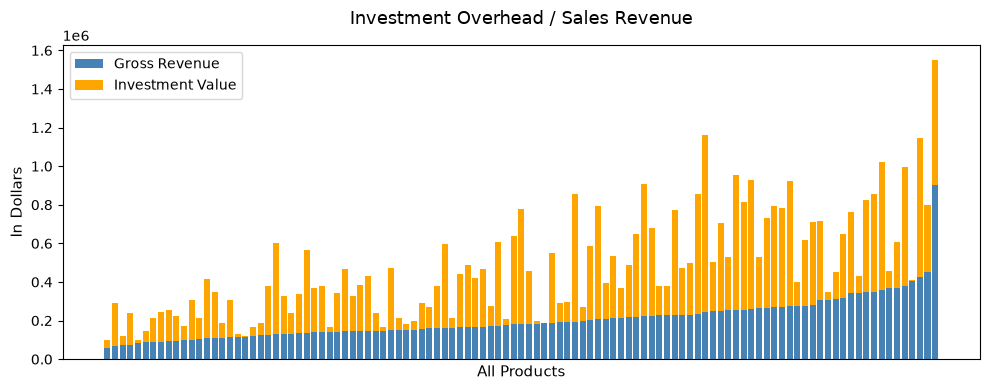

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(df_OH['productCode'], df_OH['grossRevenue'], color='steelblue').set_label('Gross Revenue')
ax.bar(df_OH['productCode'], df_OH['investmentValue'], bottom=df_OH['grossRevenue'], color='orange').set_label('Investment Value')
ax.legend()

ax.set_xticks([])
ax.set_title('Investment Overhead / Sales Revenue', fontsize=13, pad=15)
ax.set_xlabel('All Products', fontsize=11)
ax.set_ylabel('In Dollars', fontsize=11)

plt.tight_layout()
plt.show()
plt.close('all')

- Overall, sales look reasonable across all product codes with no serious problems in terms of extreme poor sales performance.
- The amount of inventory for each product code is fairly inconsistent.
- Several products show extremely low inventory on hand.

## Sort Products by Warehouse

In [8]:
df_WH = df.groupby(['warehouseCode', 'productCode', 'investmentValue'])['grossRevenue'].sum().sort_values().reset_index()
df_WH.head()

,warehouseCode,productCode,investmentValue,grossRevenue
0,b,S24_2840,40443.22,57481.15
1,a,S32_2206,223077.74,69291.41
2,c,S24_3969,45261.75,73419.21
3,c,S24_1937,165483.24,74553.29
4,c,S18_2248,17982.00,83767.75


In [9]:
df_WHa = df_WH[(df_WH['warehouseCode'] == 'a')].sort_values('grossRevenue')
df_WHb = df_WH[(df_WH['warehouseCode'] == 'b')].sort_values('grossRevenue')
df_WHc = df_WH[(df_WH['warehouseCode'] == 'c')].sort_values('grossRevenue')
df_WHd = df_WH[(df_WH['warehouseCode'] == 'd')].sort_values('grossRevenue')

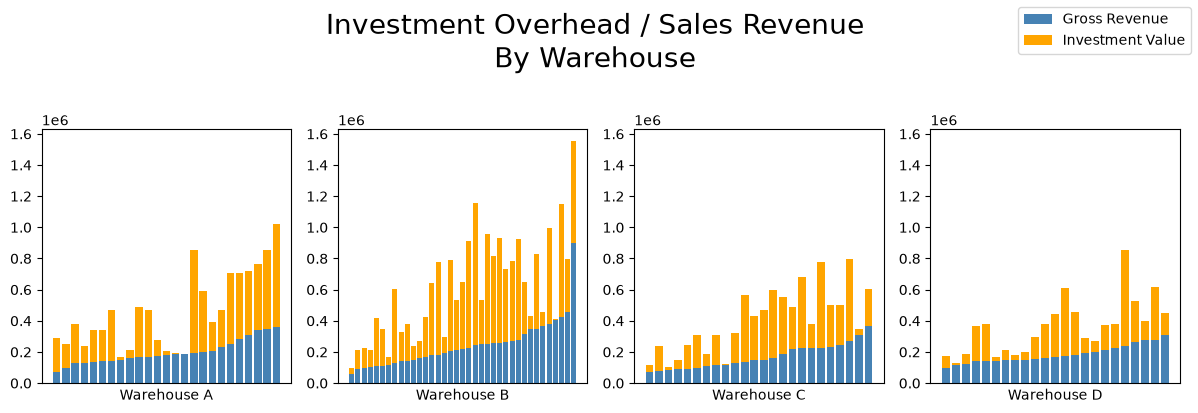

In [10]:
fig, ax = plt.subplots(1, 4, figsize=(12, 4))

fig.suptitle('Investment Overhead / Sales Revenue\nBy Warehouse', fontsize=20, y=1.02)

ax[0].bar(df_WHa['productCode'], df_WHa['grossRevenue'], color='steelblue').set_label('Gross Revenue')
ax[0].bar(df_WHa['productCode'], df_WHa['investmentValue'], bottom=df_WHa['grossRevenue'], color='orange').set_label('Investment Value')
ax[0].set_xlabel("Warehouse A")
ax[0].set_xticks([])

ax[1].bar(df_WHb['productCode'], df_WHb['grossRevenue'], color='steelblue')
ax[1].bar(df_WHb['productCode'], df_WHb['investmentValue'], bottom=df_WHb['grossRevenue'], color='orange')
ax[1].set_xlabel("Warehouse B")
ax[1].set_xticks([])

ax[2].bar(df_WHc['productCode'], df_WHc['grossRevenue'], color='steelblue')
ax[2].bar(df_WHc['productCode'], df_WHc['investmentValue'], bottom=df_WHc['grossRevenue'], color='orange')
ax[2].set_xlabel("Warehouse C")
ax[2].set_xticks([])

ax[3].bar(df_WHd['productCode'], df_WHd['grossRevenue'], color='steelblue')
ax[3].bar(df_WHd['productCode'], df_WHd['investmentValue'], bottom=df_WHd['grossRevenue'], color='orange')
ax[3].set_xlabel("Warehouse D")
ax[3].set_xticks([])

fig.legend()

ax[1].sharey(ax[0])
ax[2].sharey(ax[0])
ax[3].sharey(ax[0])

plt.tight_layout()
plt.show()
plt.close('all')

- All warehouses are selling inventory with reasonable distributions.
- All warehouses contain some products which appear to contain insufficient stock levels based on previous sales.
- Depending on the resons behind the low inventory of certain products it may be advisable to discontinue those particular products.

## Check Low-Stock by Manufacturer

- Check for low stock by the current investment in inventory by product code.
- Inspect whether there is any correlation between low-stock items and any particular manufacturer.

In [11]:
df_LS = df.groupby([ 'productVendor', 'productCode', 'warehouseCode', 'investmentValue'])['grossRevenue'].sum().reset_index()
df_LS = df_LS.sort_values('investmentValue')
df_LS.head(10)

,productVendor,productCode,warehouseCode,investmentValue,grossRevenue
48,Highway 66 Mini Classics,S24_2000,a,559.80,184872.72
50,Highway 66 Mini Classics,S32_4289,c,4490.72,116846.98
0,Autoart Studio Design,S12_1099,b,6483.12,405790.13
35,Exoto Designs,S32_1374,a,11911.76,184494.69
100,Unimax Art Galleries,S72_3212,d,13786.20,115385.28
63,Motor City Art Classics,S18_2248,c,17982.00,83767.75
6,Autoart Studio Design,S50_4713,a,20502.00,147570.78
75,Red Start Diecast,S32_3522,d,27358.54,139560.92
68,Motor City Art Classics,S700_3167,a,29974.40,177948.80
92,Studio M Art Models,S700_1938,d,31912.10,149632.93


- Seven out of 13 product vendors are represented in the Top10 lowest inventory query.

## Reinspect the Overhead Graphs Sorted by Product Vendor

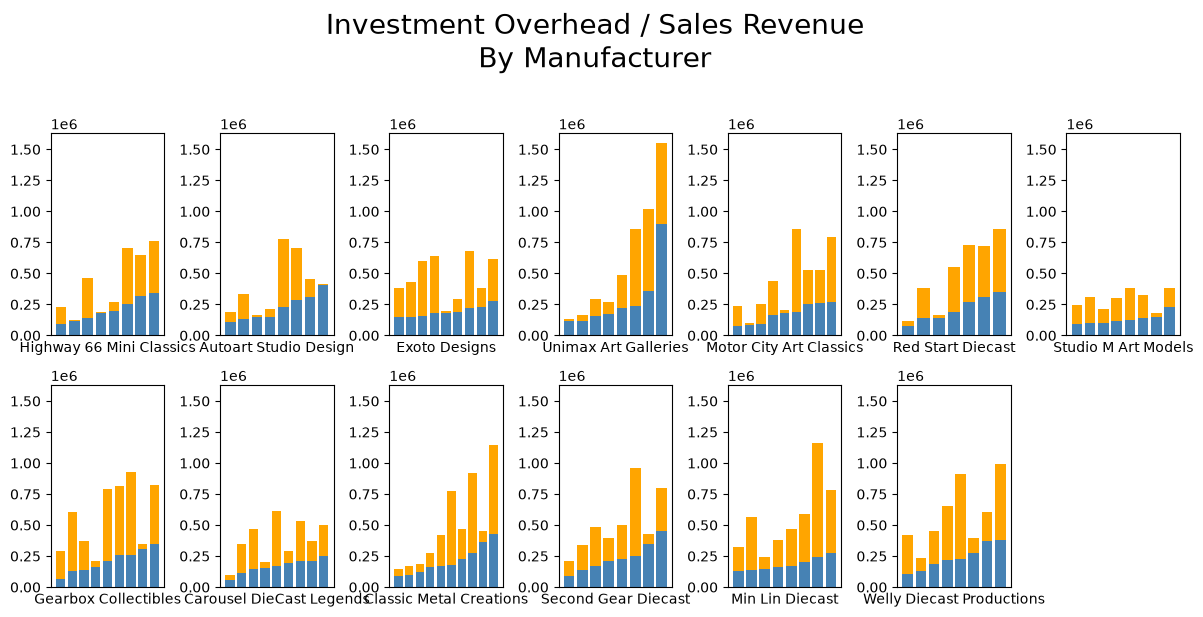

In [12]:
vendors = df_LS['productVendor'].unique()
vendor_dfs = []

for vendor in vendors:
    df_temp = df_LS[(df_LS['productVendor'] == vendor)].sort_values('grossRevenue')
    vendor_dfs.append(df_temp)


fig, axes = plt.subplots(2, 7, figsize=(12, 6))
ax = axes.flatten()

fig.suptitle('Investment Overhead / Sales Revenue\nBy Manufacturer', fontsize=20, y=1.02)

for i in range(len(vendors)):
    Vendor = vendors[i]
    df_temp = vendor_dfs[i]

    ax[i].bar(df_temp['productCode'],
          df_temp['grossRevenue'],
          color='steelblue'
         )

    ax[i].bar(df_temp['productCode'],
          df_temp['investmentValue'],
          color='orange',
          bottom=df_temp['grossRevenue']
         )

    ax[i].set_xlabel(vendors[i])
    ax[i].set_xticks([])
    ax[i].sharey(ax[0])

ax[13].set_axis_off()
plt.tight_layout()
plt.show()
plt.close('all')

- Clearly now, issues regarding low-stock inventory are with respect to individual products and not the fault of any single suppier.
- Low stock levels are not directly correlated to high sales volumes in most cases.
- The dataset lacks the necessary product supply information required to investigate any further at this time.

## Check Warehouse Volumes

- Actual packaging volume information was not available.
- A list of the approximate product volumes has been generated based on product names and scale for the purpose of analysis.

In [13]:
df_cap = pd.read_csv('CSV_Files/capacityInfo.csv')
df_cap['warehouseCode'] = df_cap['warehouseCode'].str.upper()
df_cap

,warehouseCode,warehousePctCap,stockVolume,warehouseCapacity,spaceRemaining
0,A,72,13288.2293,18455.874028,5167.644728
1,B,67,23207.0423,34637.376567,11430.334267
2,C,50,6936.7398,13873.479600,6936.739800
3,D,75,7891.7998,10522.399733,2630.599933


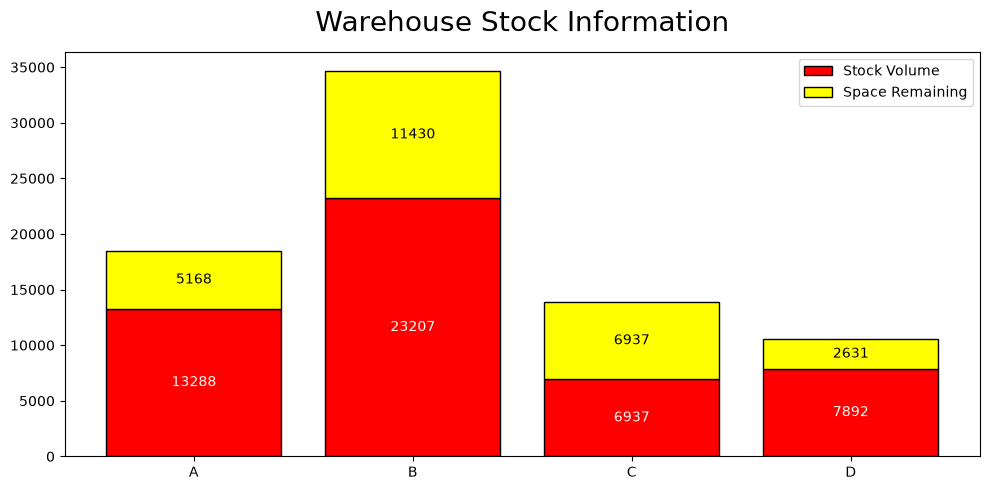

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

rects1 = ax.bar(df_cap['warehouseCode'],
           df_cap['stockVolume'],
           color='red',
           edgecolor='black',
           label ='Stock Volume')

rects2 = ax.bar(df_cap['warehouseCode'],
           df_cap['spaceRemaining'],
           bottom=df_cap['stockVolume'],
           color='yellow',
           edgecolor='black',
           label='Space Remaining')

ax.bar_label(rects1, fmt='%.0f', label_type='center', color='white')
ax.bar_label(rects2, fmt='%.0f', label_type='center')

ax.set_title('Warehouse Stock Information', fontsize=20, pad=15)
ax.legend()

plt.tight_layout()
plt.show()
plt.close('all')

- The largest warehouse, Warehouse B, shows enough space remaining to hold the stock from either Warehouse C or Warehouse D.
- Considering that Warehouse C is half-empty, this may a good candidate for closure.

In [15]:
df_PL = pd.read_csv('CSV_Files/avgProductLineVolume.csv')
df_PL = df_PL.sort_values(by='warehouseCode')
df_PL

,warehouseCode,productLine,averageProductVolume
1,a,Planes,0.016425
5,a,Motorcycles,0.136623
4,b,Classic Cars,0.113468
3,c,Vintage Cars,0.054325
0,d,Ships,0.011333
2,d,Trains,0.021433
6,d,Trucks and Buses,0.150755


- It can be seen that the large warehouse "B" contains only 'Classic Cars'.
- The warehouse which is a candidate for closure, "C", contains only 'Vintage Cars'.
- Merging the contents of warehouses B and C would allow for the full stock of 'Cars' to be housed in a single location.

## Look into Warehouse Shipping Efficiency

- Check the amount of time each warehouse requires to ship an order.
- Look for shipping delays from each warehouse.
- Determine if shipping delays are incidental or a systemic issue.

In [16]:
df_SI = pd.read_csv('CSV_Files/shippingInfo.csv')
df_SI.head()

,orderNumber,warehouseCode,productCode,daysToShipping,lineTotal
0,10210,a,S10_2016,8,2598.77
1,10210,a,S10_4698,8,6452.86
2,10210,a,S18_1662,8,4399.52
3,10210,a,S18_2581,8,3421.50
4,10210,a,S18_2625,8,2059.20


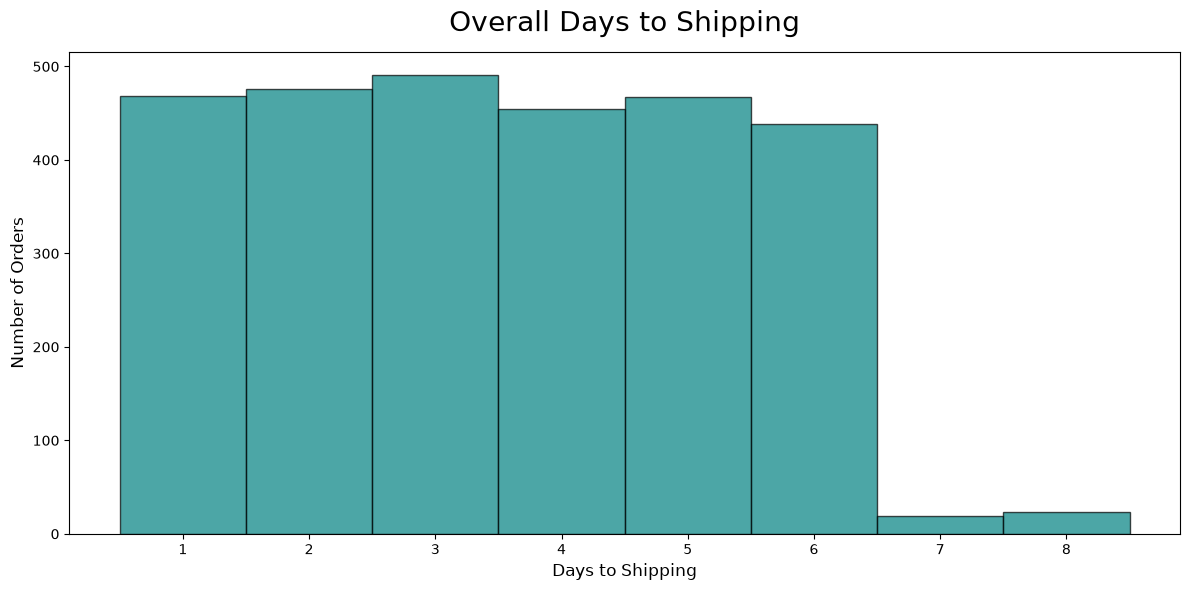

In [19]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# 1. Setup data
x = df_SI["daysToShipping"]

# 2. Set up a spacious canvas
plt.figure(figsize=(12, 6))

plt.hist(x, bins=[i + 0.5 for i in range(9)], color='teal', edgecolor='black', alpha=0.7)
plt.xticks(range(1, 9))

plt.title('Overall Days to Shipping', fontsize=20, pad=15)
plt.xlabel('Days to Shipping', fontsize=12)


plt.ylabel('Number of Orders', fontsize=12)

plt.tight_layout()
plt.show()
plt.close('all')

#### Orders shipped from multiple warehouses DO NOT differentiate their date of shipment from each warehouse individually, THEREFORE the aggregated totals for each will only show a difference if a given warehouse is performing differently than average.

## Warehouse Shipping Efficiency (cont'd)

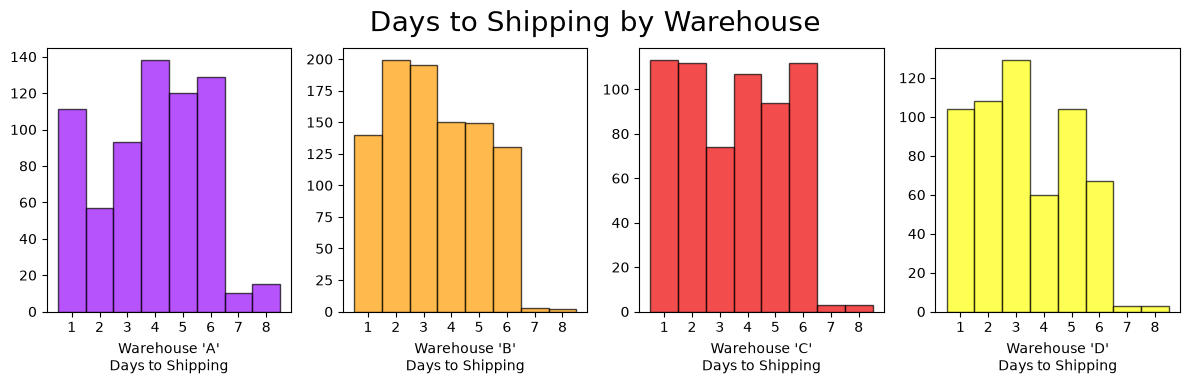

In [20]:
warehouses = sorted(df_SI['warehouseCode'].unique())
num = len(warehouses)
warehouse_list = []

colors = ['#970afa', '#ff9c00', '#ef0000', '#fdff08']

fig, ax = plt.subplots(1, num, figsize=(12, 4))

for warehouse in warehouses:
    df_temp = df_SI[df_SI['warehouseCode'] == warehouse]['daysToShipping']
    warehouse_list.append(df_temp)

for i, warehouse in enumerate(warehouses):
    ax[i].hist(warehouse_list[i], bins=[b + 0.5 for b in range(9)], color=colors[i % len(colors)], edgecolor='black', alpha=0.7)
    ax[i].set_xticks(range(1, 9))
    ax[i].set_xlabel(f'Warehouse \'{warehouse.upper()}\'\nDays to Shipping', fontsize=10)
    

fig.suptitle('Days to Shipping by Warehouse', fontsize=20, y=0.95)
plt.tight_layout()
plt.show()
plt.close('all')


#### After splitting the shipping delays into occurances by location, normalized to maximum orders per bin:

- Warehouse 'B' has proportionally more One-Day shipping delays than the other warehouses.
- If warehouse 'C' were to be moved into warehouse 'B' then warehouse 'B' must be able to accomodate an extra 100 orders worth of source/process/ship per day.
- If the One-Day and Two-Day shipping delays associated with warehouse 'B' are the result of order volume, staffing, or warehouse operations efficiency, then these potential bottlenecks should be rectified prior to moving extra inventory into warehouse 'B'.

## Next Steps:

#### - Compare the actual volumes of Warehouse B and Warehouse C against the estimated model

- It is extremely important to remember that the amount of space that any given portion of inventory shall occupy has been estimated here without the spacial burden of the items' packaging.
- It would be unsurprising to discover that the smaller scale models of current Warehouse C have proportionally more packaging than the somewhat larger models currently occupying Warehouse B.
- Both Warehouse B and Warehouse C will, in reality, be much larger than the generated volumes which were used to compare warehouse capacities.  Comparing the ratio of (Actual:Estimated) warehouse volume for each warehouse could possibly be used in lieu of ascertaining complete product packaging size information.

#### - Look into the reasons why some items have incredibly low inventory stock

- Are any of these items no longer availible or difficult to acquire from the manufacturer?
- If so, consider dropping those products from the Mint Classics products catalogue.
- This method could be useful in warehouse reorganization more storage volume might be achieved from the same square footage with less individual product codes to keep organized and accessible.

#### - Consider the ability to handle the logistics of increased shipping from Warehouse B

- At the outset of this analysis, Mint Classics expressed an interest in being able to ship products within 24 hours of recieving a purchase order.
- The warehouse to which the inventory of the proposed closure would be moved has a higher proportion of 2-3 day delays than the other warehouses.
- Ensure that warehouse staffing and logistics in Warehouse B will be capable of accomodating the estimated 100 extra line items of orders per day after ammalgamation.
- Condense the existing inventory in Warehouse B creating a completely seperate and empty space for the inventory of Warehouse C prior to shutting down Warehouse.

## Please feel free to come back with any other more specific questions regarding any aspect of this ongoing project.

# Thank You for choosing BCPMcustom Analytics!